# 0.0 IMPORTS

In [3]:
import pandas as pd
import inflection
import math
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.core.display import HTML
from IPython.display import Image as image
from datetime import datetime, timedelta

## 0.1 Helper Functions

## 0.2 Loading data

In [4]:
# Dataset import
df_sales_raw = pd.read_csv("../Dataset/train.csv", low_memory=False)
df_store_raw = pd.read_csv("../Dataset/store.csv", low_memory=False)

# Merging datasets
df_raw = pd.merge(df_sales_raw, df_store_raw, how="left", on="Store")


## 1.0 Descrição dos Dados

### 1.1 Rename Columns

In [5]:
df1 = df_raw.copy()

In [6]:
df1.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval'],
      dtype='str')

In [7]:
cols_old = ['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval']

In [8]:
# Renaming columns
snakecase = lambda x: inflection.underscore(x)
cals_new = list(map(snakecase, cols_old))

df1.columns = cals_new
df1.columns

Index(['store', 'day_of_week', 'date', 'sales', 'customers', 'open', 'promo',
       'state_holiday', 'school_holiday', 'store_type', 'assortment',
       'competition_distance', 'competition_open_since_month',
       'competition_open_since_year', 'promo2', 'promo2_since_week',
       'promo2_since_year', 'promo_interval'],
      dtype='str')

### 1.2 Data Dimension

In [9]:
df1.shape

(1017209, 18)

In [10]:
print("Number of rows: ", (df1.shape[0]))
print("Number of columns: ", (df1.shape[1]))

Number of rows:  1017209
Number of columns:  18


### 1.3 Data Types

In [11]:
df1.dtypes

store                             int64
day_of_week                       int64
date                                str
sales                             int64
customers                         int64
open                              int64
promo                             int64
state_holiday                       str
school_holiday                    int64
store_type                          str
assortment                          str
competition_distance            float64
competition_open_since_month    float64
competition_open_since_year     float64
promo2                            int64
promo2_since_week               float64
promo2_since_year               float64
promo_interval                      str
dtype: object

In [12]:
df1['date'] = pd.to_datetime(df1['date'])
df1['promo_interval'] = df1['promo_interval'].astype(object)
df1.dtypes

store                                    int64
day_of_week                              int64
date                            datetime64[us]
sales                                    int64
customers                                int64
open                                     int64
promo                                    int64
state_holiday                              str
school_holiday                           int64
store_type                                 str
assortment                                 str
competition_distance                   float64
competition_open_since_month           float64
competition_open_since_year            float64
promo2                                   int64
promo2_since_week                      float64
promo2_since_year                      float64
promo_interval                          object
dtype: object

In [13]:
df1.head(5)


,store,day_of_week,date,sales,customers,open,promo,state_holiday,school_holiday,store_type,assortment,competition_distance,competition_open_since_month,competition_open_since_year,promo2,promo2_since_week,promo2_since_year,promo_interval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


### 1.4 Check NA

In [14]:
df1.isna().sum()

store                                0
day_of_week                          0
date                                 0
sales                                0
customers                            0
open                                 0
promo                                0
state_holiday                        0
school_holiday                       0
store_type                           0
assortment                           0
competition_distance              2642
competition_open_since_month    323348
competition_open_since_year     323348
promo2                               0
promo2_since_week               508031
promo2_since_year               508031
promo_interval                  508031
dtype: int64

### 1.5 Fillout NA

In [15]:
df1['competition_distance'].max()

np.float64(75860.0)

In [16]:
# competition_distance
df1['competition_distance']= df1['competition_distance'].apply (lambda x: 200000.0 if math.isnan(x) else x)
           
# competition_open_since_month
df1['competition_open_since_month'] = df1.apply ( lambda x: x["date"].month if math.isnan(x['competition_open_since_month'])else x['competition_open_since_month'], axis=1)

# competition_open_since_year
df1['competition_open_since_year'] = df1.apply ( lambda x: x["date"].year if math.isnan(x['competition_open_since_year'])else x['competition_open_since_year'], axis=1)

# promo2_since_week
df1['promo2_since_week'] = df1.apply ( lambda x: x["date"].week if math.isnan(x['promo2_since_week'])else x['promo2_since_week'], axis=1)         

# promo2_since_year
df1['promo2_since_year'] = df1.apply ( lambda x: x["date"].year if math.isnan(x['promo2_since_year'])else x['promo2_since_year'], axis=1)

# promo_interval
month_map = {1: 'Jan', 2: 'Fev', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dez',}

df1['promo_interval']= df1['promo_interval'].fillna ('0')
df1['month_map'] = df1['date'].dt.month.map(month_map)
df1['promo_interval'].unique()
df1['is_promo']= df1[['promo_interval', 'month_map']].apply(lambda x: 0 if x['promo_interval']=='0' else 1 if x['month_map']in x['promo_interval'].split(',') else 0, axis=1)

In [17]:
df1.isna().sum()

store                           0
day_of_week                     0
date                            0
sales                           0
customers                       0
open                            0
promo                           0
state_holiday                   0
school_holiday                  0
store_type                      0
assortment                      0
competition_distance            0
competition_open_since_month    0
competition_open_since_year     0
promo2                          0
promo2_since_week               0
promo2_since_year               0
promo_interval                  0
month_map                       0
is_promo                        0
dtype: int64

### 1.6 Change Types

In [18]:
df1['competition_open_since_month']=df1['competition_open_since_month'].astype(int)
df1['competition_open_since_year']=df1['competition_open_since_year'].astype(int)
df1['promo2_since_week']=df1['promo2_since_week'].astype(int)
df1['promo2_since_year']=df1['promo2_since_year'].astype(int)
df1['promo_interval']=df1['promo_interval'].astype(str)

df1.dtypes

store                                    int64
day_of_week                              int64
date                            datetime64[us]
sales                                    int64
customers                                int64
open                                     int64
promo                                    int64
state_holiday                              str
school_holiday                           int64
store_type                                 str
assortment                                 str
competition_distance                   float64
competition_open_since_month             int64
competition_open_since_year              int64
promo2                                   int64
promo2_since_week                        int64
promo2_since_year                        int64
promo_interval                             str
month_map                                  str
is_promo                                 int64
dtype: object

### 1.7 Descripted Statistical

In [19]:
num_attributes = df1.select_dtypes(include=['int64', 'float64'])
cat_attributes = df1.select_dtypes(exclude=['int64', 'float64', 'datetime64[ns]'])
cat_attributes.head()

,state_holiday,store_type,assortment,promo_interval,month_map
0,0,c,a,0,Jul
1,0,a,a,"Jan,Apr,Jul,Oct",Jul
2,0,a,a,"Jan,Apr,Jul,Oct",Jul
3,0,c,c,0,Jul
4,0,a,a,0,Jul


In [20]:
cat_attributes.dtypes

state_holiday     str
store_type        str
assortment        str
promo_interval    str
month_map         str
dtype: object

In [21]:
cat_attributes.shape

(1017209, 5)

### 1.7.1 Numerical Attributes

In [22]:
# Central tendency - mean, median
ct1 =pd.DataFrame(num_attributes.apply(np.mean)).transpose()
ct2 =pd.DataFrame(num_attributes.apply(np.median)).transpose()

# Dispersion - std (standard deviation/desvio padrão), min, max, range, quartiles
d1 = pd.DataFrame(num_attributes.apply(np.std)).transpose()
d2 = pd.DataFrame(num_attributes.apply(min)).transpose()
d3 = pd.DataFrame(num_attributes.apply(max)).transpose()
d4 = pd.DataFrame(num_attributes.apply(lambda x: x.max() - x.min())).transpose()

# Measures of shape - skewness, kurtosis (assimetria = 0 proximo da normal, curtose = 1 proximo da normal) 
# Todos os pontos estão concentrados no centro, caudas mais leves, distribuição mais achatada do que a normal, curtose < 3, caudas mais pesadas, distribuição mais pontuda do que a normal, curtose > 3
d5 = pd.DataFrame(num_attributes.apply(lambda x: x.skew())).transpose()
d6 = pd.DataFrame(num_attributes.apply(lambda x: x.kurtosis())).transpose()

# Concatenating tables
m = pd.concat([d2, d3, d4, ct1, ct2, d1, d5, d6]).T.reset_index()
m.columns = ['attributes', 'min', 'max', 'range', 'mean', 'median', 'std', 'skewness', 'kurtosis']
m

,attributes,min,max,range,mean,median,std,skewness,kurtosis
0,store,1.0,1115.0,1114.0,558.429727,558.0,321.908493,-0.000955,-1.200524
1,day_of_week,1.0,7.0,6.0,3.998341,4.0,1.997390,0.001593,-1.246873
2,sales,0.0,41551.0,41551.0,5773.818972,5744.0,3849.924283,0.641460,1.778375
3,customers,0.0,7388.0,7388.0,633.145946,609.0,464.411506,1.598650,7.091773
4,open,0.0,1.0,1.0,0.830107,1.0,0.375539,-1.758045,1.090723
5,promo,0.0,1.0,1.0,0.381515,0.0,0.485758,0.487838,-1.762018
6,school_holiday,0.0,1.0,1.0,0.178647,0.0,0.383056,1.677842,0.815154
7,competition_distance,20.0,200000.0,199980.0,5935.442677,2330.0,12547.646829,10.242344,147.789712
8,competition_open_since_month,1.0,12.0,11.0,6.786849,7.0,3.311085,-0.042076,-1.232607
9,competition_open_since_year,1900.0,2015.0,115.0,2010.324840,2012.0,5.515591,-7.235657,124.071304


<Axes: xlabel='sales', ylabel='Count'>

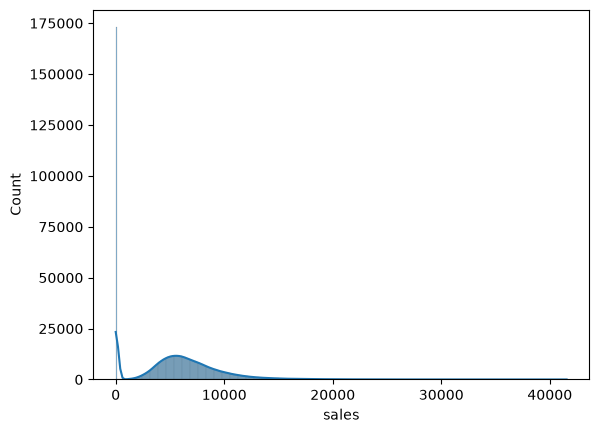

In [23]:
sns.histplot(df1['sales'], kde=True)

<Axes: xlabel='competition_distance', ylabel='Count'>

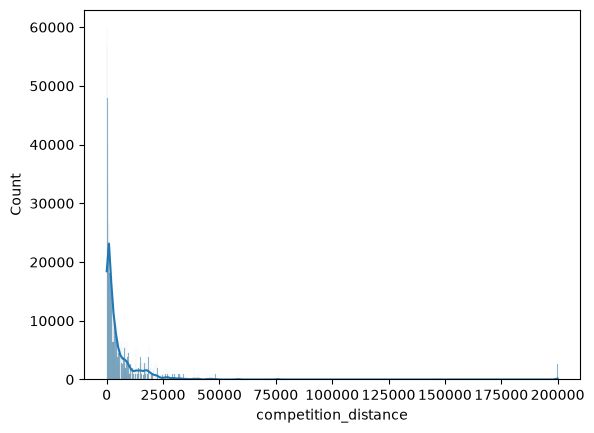

In [24]:
sns.histplot(df1['competition_distance'], kde=True)

### 1.7.2 Categorical Attributes

In [25]:
cat_attributes.apply(lambda x: x.nunique())

state_holiday      4
store_type         4
assortment         3
promo_interval     4
month_map         12
dtype: int64

<Axes: xlabel='assortment', ylabel='sales'>

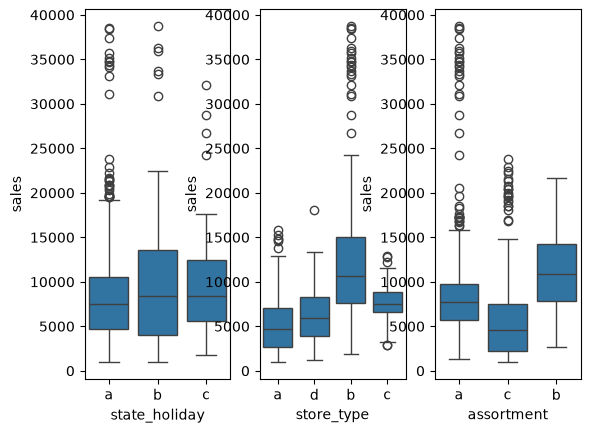

In [26]:
aux1 = df1[(df1['sales']>0) & (df1['state_holiday']!='0')]
# col, lin, posição do gráfico
plt.subplot(1,3,1)
sns.boxplot(x='state_holiday', y='sales', data=aux1)

plt.subplot(1,3,2)
sns.boxplot(x='store_type', y='sales', data=aux1)

plt.subplot(1,3,3)
sns.boxplot(x='assortment', y='sales', data=aux1)

## Elementos de mapa mental de hipóteses:

1) Fenômeno: o que está tentando medir ou modelar (resultado = y).

2) Agentes: agentes que impactam seu fenômeno (features = x)

3) Atributos do agente: características dos atributos.

## Hipóteses são geradas por:

1) Surpresa: insight com hipóteses não analisadas.

2) Teste de crença: verificar se a contraposição da crença é validada ou não.

## 2.0 Feature Engineering

### Mapa Mental de Hipóteses

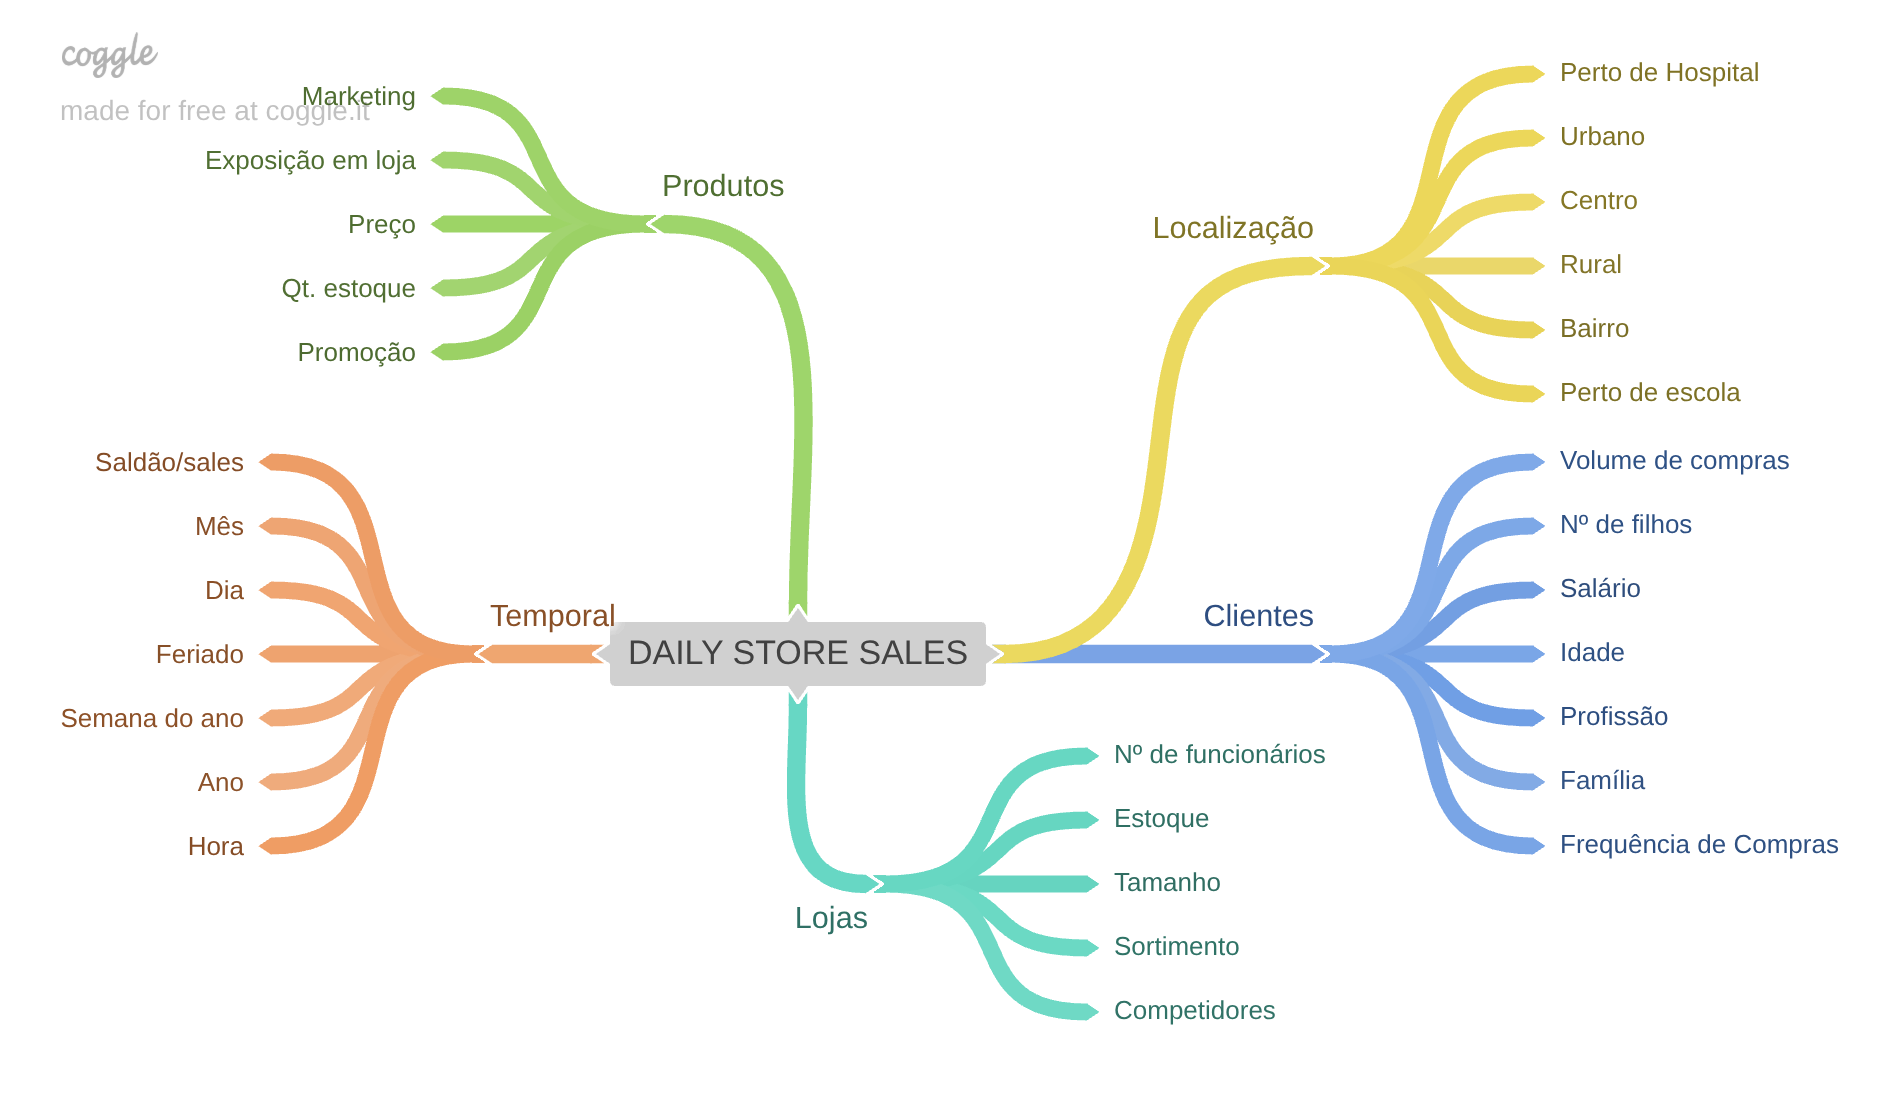

In [27]:
image('c:/repos/Rossmann_Project/img/MindmapHypothesis.png')

### 2.1 Criação das hipóteses

#### 2.1.1 Hipóteses Loja

**1** Lojas com maior quadro de funcionários vendem mais.

**2** Lojas com maior capacidade de estoque vendem mais.

**3** Lojas com maior porte vendem mais.

**4** Lojas com maior sortimento vendem mais.

**4** Lojas com competidores mais próximos vendem menos.

**6** Lojas com competidores a mais tempo vendem mais.

#### 2.1.2 Hipóteses Produto

**1** Lojas com maior investimento em marketing vendem mais.

**2** Lojas com maior exposição de produtos vendem mais.

**3** Lojas com menores preços vendem mais.

**4** Lojas com promoções mais agressivas (descontos amiores) vendem mais.

**5** Lojas com promoções ativas por mais tempo vendem mais.

**6** Lojas com mais dias de promoção vendem mais.

**7** Lojas com promoções consecutivas vendem mais.

#### 2.1.3 Hipóteses Temporal

**1** Lojas abertas nos feriados de Natal vendem mais.

**2** Lojas ao longo dos anos vendem mais.

**3** Lojas vendem mais no segundo semestre do ano.

**4** Lojas vendem mais após o dia 10 de cada mês.

**5** Lojas vendem menos aos finais de semana.

**6** Lojas vendem menos durante os feriados escolares.

### 2.2 Lista final de Hipóteses 

### Hipóteses com dados disponíveis:

**1** Lojas com maior sortimento vendem mais.

**2** Lojas com competidores mais próximos vendem menos.

**3** Lojas com competidores a mais tempo vendem mais.

**4** Lojas vendem mais após o dia 10 de cada mês.

**5** Lojas vendem menos aos finais de semana.

**6** Lojas vendem menos durante os feriados escolares.

**7** Lojas abertas nos feriados de Natal vendem mais.

**8** Lojas ao longo dos anos vendem mais.

**9** Lojas vendem mais no segundo semestre do ano.

**10** Lojas vendem mais após o dia 10 de cada mês.

**11** Lojas vendem menos aos finais de semana.

**12** Lojas vendem menos durante os feriados escolares.

#### Feature Engineering

In [28]:
df2 = df1.copy()

In [29]:
df2.dtypes

store                                    int64
day_of_week                              int64
date                            datetime64[us]
sales                                    int64
customers                                int64
open                                     int64
promo                                    int64
state_holiday                              str
school_holiday                           int64
store_type                                 str
assortment                                 str
competition_distance                   float64
competition_open_since_month             int64
competition_open_since_year              int64
promo2                                   int64
promo2_since_week                        int64
promo2_since_year                        int64
promo_interval                             str
month_map                                  str
is_promo                                 int64
dtype: object

In [30]:
# year
df2['year'] = df2['date'].dt.year

# month
df2['month'] = df2['date'].dt.month

# day
df2['day'] = df2['date'].dt.day

# week of year
df2['week_year'] = df2['date'].dt.isocalendar().week

# year week
df2['year_week'] = df2['date'].dt.strftime( '%Y-%W' )

from datetime import datetime

# competition since axis=0 (verticalmente, coluna por coluna) e axis=1 (horizontalmente, linha por linha)
df2['competition_since'] = df2.apply(
    lambda x: datetime(
        year=int(x['competition_open_since_year']),
        month=int(x['competition_open_since_month']),
        day=1
    ),
    axis=1
)

# competition since
df2['competition_since'] = df2.apply( 
    lambda x: datetime( year=x['competition_open_since_year'], 
                       month=x['competition_open_since_month'],
                       day=1 
                       ), 
    axis=1 
    )

# competition_time_month ou tempo da competição em meses
df2['competition_time_month'] = ( 
    ( df2['date'] - df2['competition_since'] )/30 ).apply( lambda x: x.days
                                                          ).astype( int )
                                                                                          
# promo since
df2['promo_since'] = df2['promo2_since_year'].astype(str) + '-' + df2['promo2_since_week'].astype(str)
from datetime import datetime, timedelta

df2['promo_since'] = df2['promo_since'].apply(
    lambda x: datetime.strptime(x + '-1', '%Y-%W-%w') - timedelta(days=7)
)
df2['promo_time_week'] = ((df2['date'] - df2['promo_since']) /7).apply(lambda x: x.days).astype(int)

# assortment
df2['assortment'] = df2['assortment'].apply( lambda x: 'basic' if x == 'a' else 'extra' if x == 'b' else 'extended' )

# state holiday
df2['state_holiday'] = df2['state_holiday'].apply( lambda x: 'public_holiday' if x == 'a' else 'easter_holiday' if x == 'b' else 'christmas' if x == 'c' else 'regular_day' )

In [31]:
df2[['year', 'month','day','week_year','year_week', 'competition_since', 'competition_time_month','promo_since','promo_time_week','assortment','state_holiday']].head().T


,0,1,2,3,4
year,2015,2015,2015,2015,2015
month,7,7,7,7,7
day,31,31,31,31,31
week_year,31,31,31,31,31
year_week,2015-30,2015-30,2015-30,2015-30,2015-30
competition_since,2008-09-01 00:00:00,2007-11-01 00:00:00,2006-12-01 00:00:00,2009-09-01 00:00:00,2015-04-01 00:00:00
competition_time_month,84,94,105,71,4
promo_since,2015-07-27 00:00:00,2010-03-22 00:00:00,2011-03-28 00:00:00,2015-07-27 00:00:00,2015-07-27 00:00:00
promo_time_week,0,279,226,0,0
assortment,basic,basic,basic,extended,basic


## 3.0 Filtragem de Variáveis

In [101]:
df3 = df2.copy()

### 3.2 Seleção das Colunas

In [102]:
cols_drop = ['customers', 'promo_interval', 'month_map']
df3 = df3.drop(cols_drop, axis=1)

In [103]:
df3.columns

Index(['store', 'day_of_week', 'date', 'sales', 'open', 'promo',
       'state_holiday', 'school_holiday', 'store_type', 'assortment',
       'competition_distance', 'competition_open_since_month',
       'competition_open_since_year', 'promo2', 'promo2_since_week',
       'promo2_since_year', 'is_promo', 'year', 'month', 'day', 'week_year',
       'year_week', 'competition_since', 'competition_time_month',
       'promo_since', 'promo_time_week'],
      dtype='str')

### 3.1 Filtragem das Linhas

In [104]:
df3 = df3[(df3['open'] != 0 ) & (df3['sales'] > 0)]

In [105]:
df3.head()

,store,day_of_week,date,sales,open,promo,state_holiday,school_holiday,store_type,assortment,...,is_promo,year,month,day,week_year,year_week,competition_since,competition_time_month,promo_since,promo_time_week
0,1,5,2015-07-31,5263,1,1,regular_day,1,c,basic,...,0,2015,7,31,31,2015-30,2008-09-01,84,2015-07-27,0
1,2,5,2015-07-31,6064,1,1,regular_day,1,a,basic,...,1,2015,7,31,31,2015-30,2007-11-01,94,2010-03-22,279
2,3,5,2015-07-31,8314,1,1,regular_day,1,a,basic,...,1,2015,7,31,31,2015-30,2006-12-01,105,2011-03-28,226
3,4,5,2015-07-31,13995,1,1,regular_day,1,c,extended,...,0,2015,7,31,31,2015-30,2009-09-01,71,2015-07-27,0
4,5,5,2015-07-31,4822,1,1,regular_day,1,a,basic,...,0,2015,7,31,31,2015-30,2015-04-01,4,2015-07-27,0


## 4.0 Análise Exploratória dos Dados (EDA)

In [106]:
df4 = df3.copy()

### 4.1 Análise Univariada

In [107]:
df4.columns


Index(['store', 'day_of_week', 'date', 'sales', 'open', 'promo',
       'state_holiday', 'school_holiday', 'store_type', 'assortment',
       'competition_distance', 'competition_open_since_month',
       'competition_open_since_year', 'promo2', 'promo2_since_week',
       'promo2_since_year', 'is_promo', 'year', 'month', 'day', 'week_year',
       'year_week', 'competition_since', 'competition_time_month',
       'promo_since', 'promo_time_week'],
      dtype='str')

<Axes: xlabel='sales', ylabel='Count'>

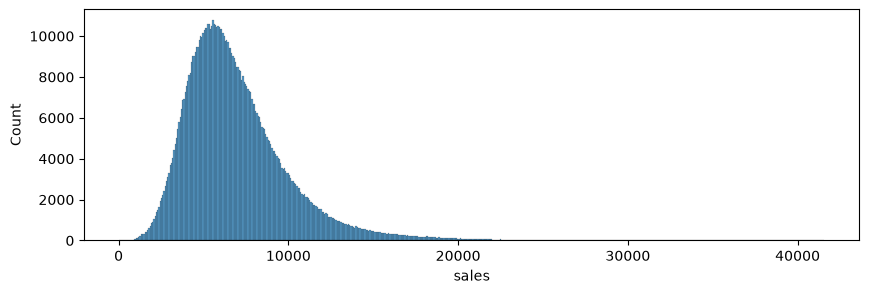

In [127]:
plt.figure(figsize=(10,3))
sns.histplot( df4['sales'], kde=False  )

array([[<Axes: title={'center': 'store'}>,
        <Axes: title={'center': 'day_of_week'}>,
        <Axes: title={'center': 'sales'}>,
        <Axes: title={'center': 'customers'}>],
       [<Axes: title={'center': 'open'}>,
        <Axes: title={'center': 'promo'}>,
        <Axes: title={'center': 'school_holiday'}>,
        <Axes: title={'center': 'competition_distance'}>],
       [<Axes: title={'center': 'competition_open_since_month'}>,
        <Axes: title={'center': 'competition_open_since_year'}>,
        <Axes: title={'center': 'promo2'}>,
        <Axes: title={'center': 'promo2_since_week'}>],
       [<Axes: title={'center': 'promo2_since_year'}>,
        <Axes: title={'center': 'is_promo'}>, <Axes: >, <Axes: >]],
      dtype=object)

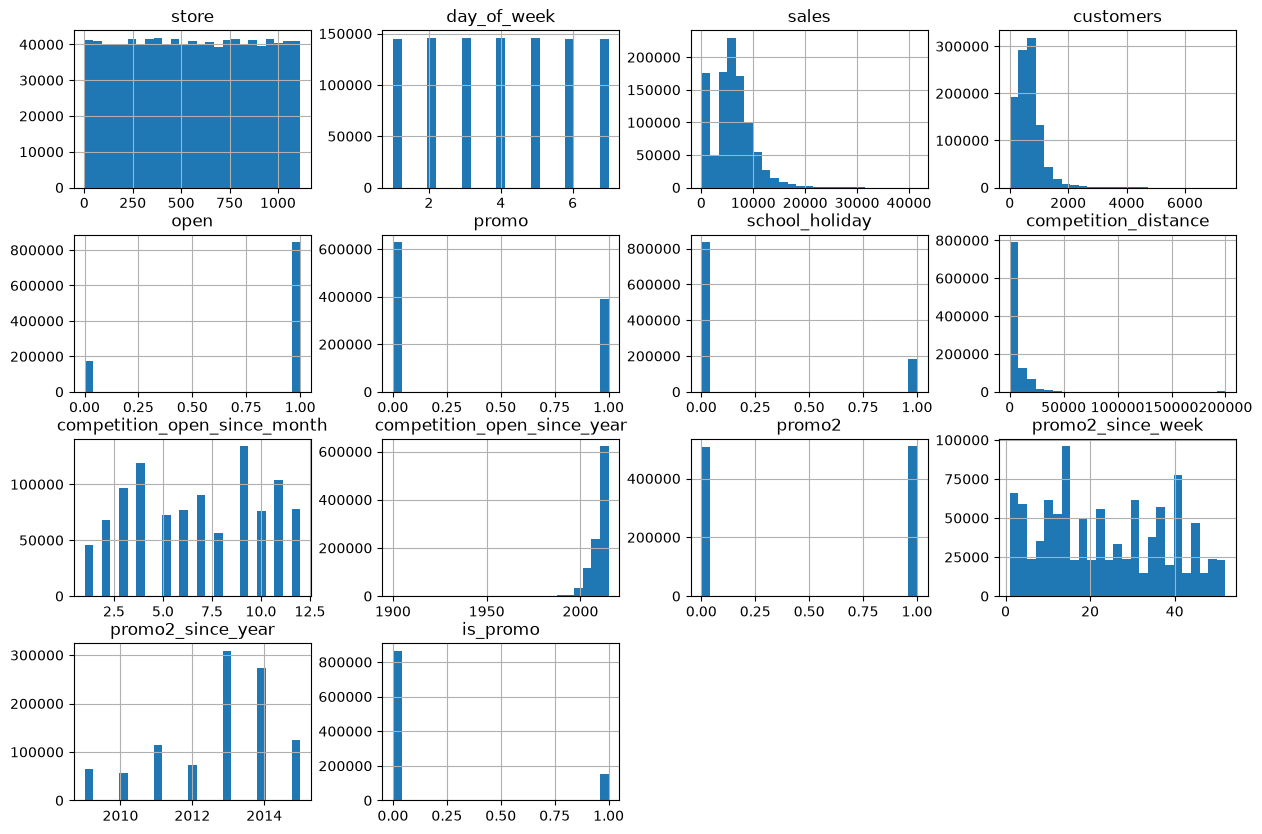

In [109]:
num_attributes.hist(bins=25, figsize=(15,10))

#### 4.1.1 Response Variable

#### 4.1.2 Numerical Variable

#### 4.1.3 Categorical Variable

In [110]:
cat_attributes.head()

,state_holiday,store_type,assortment,promo_interval,month_map
0,0,c,a,0,Jul
1,0,a,a,"Jan,Apr,Jul,Oct",Jul
2,0,a,a,"Jan,Apr,Jul,Oct",Jul
3,0,c,c,0,Jul
4,0,a,a,0,Jul


In [124]:
# contagem de linhas com cada resposta dessa variável
df4['assortment'].drop_duplicates()

0         basic
3      extended
258       extra
Name: assortment, dtype: str

<Axes: xlabel='sales', ylabel='Density'>

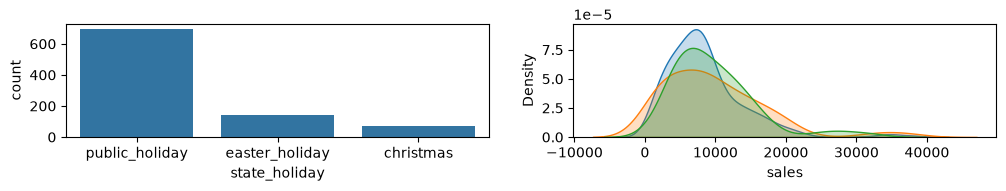

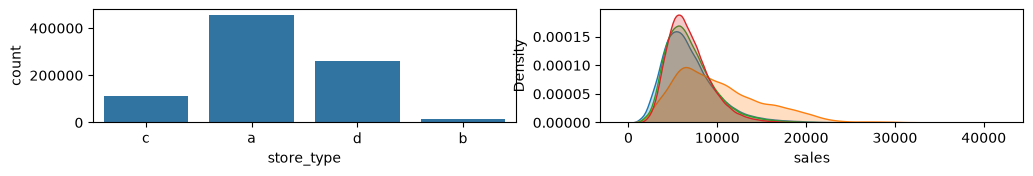

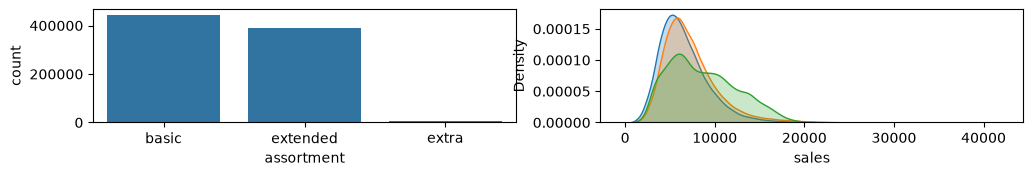

In [126]:
# state_holiday
plt.figure(figsize=(12,5))
plt.subplot( 3, 2, 1 )
a = df4[df4['state_holiday'] != 'regular_day']
sns.countplot(a['state_holiday'].reset_index() ,x='state_holiday')

plt.subplot( 3, 2, 2 )
sns.kdeplot( df4[df4['state_holiday'] == 'public_holiday']['sales'], label='public_holiday', fill=True )
sns.kdeplot( df4[df4['state_holiday'] == 'easter_holiday']['sales'], label='easter_holiday', fill=True )
sns.kdeplot( df4[df4['state_holiday'] == 'christmas']['sales'], label='christmas', fill=True )

# store_type
plt.figure(figsize=(12,5))
plt.subplot( 3, 2, 3 )
sns.countplot(df4['store_type'].reset_index() ,x='store_type')

plt.subplot( 3, 2, 4 )
sns.kdeplot( df4[df4['store_type'] == 'a']['sales'], label='a', fill=True )
sns.kdeplot( df4[df4['store_type'] == 'b']['sales'], label='b', fill=True )
sns.kdeplot( df4[df4['store_type'] == 'c']['sales'], label='c', fill=True )
sns.kdeplot( df4[df4['store_type'] == 'd']['sales'], label='d', fill=True )

# assortment
plt.figure(figsize=(12,5))
plt.subplot( 3, 2, 5 )
sns.countplot(df4['assortment'].reset_index() ,x='assortment')

plt.subplot( 3, 2, 6 )
sns.kdeplot( df4[df4['assortment'] == 'basic']['sales'], label='basic', fill=True )
sns.kdeplot( df4[df4['assortment'] == 'extended']['sales'], label='extended', fill=True )
sns.kdeplot( df4[df4['assortment'] == 'extra']['sales'], label='extra', fill=True )

### 4.1 Análise Bivariada

### 4.3 Análise Multivariada